# 06 — Driver alterations by molecular subtype

This notebook integrates TCGA-BRCA molecular subtype annotations with mutation and copy-number alteration data.

The goal is to explore whether known breast cancer driver alterations are distributed differently across molecular subtypes.

In [28]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import fisher_exact

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [29]:
PROJECT_ROOT = Path("..").resolve()

RAW_MULTIOMICS_DIR = PROJECT_ROOT / "data" / "raw" / "cbioportal_brca_multiomics"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

mutation_path = RAW_MULTIOMICS_DIR / "data_mutations.txt"
cna_path = RAW_MULTIOMICS_DIR / "data_cna.txt"
metadata_path = PROCESSED_DIR / "clinical_marker_analysis_table.tsv"

print("Mutation file exists:", mutation_path.exists())
print("CNA file exists:", cna_path.exists())
print("Metadata file exists:", metadata_path.exists())

Mutation file exists: True
CNA file exists: True
Metadata file exists: True


In [30]:
metadata = pd.read_csv(metadata_path, sep="\t")

id_cols = ["SAMPLE_ID_15", "PATIENT_ID_12"]

metadata = metadata.drop_duplicates(subset=id_cols).copy()

print("metadata:", metadata.shape)
display(metadata[["SAMPLE_ID_15", "PATIENT_ID_12", "SUBTYPE"]].head())

display(metadata["SUBTYPE"].value_counts(dropna=False))

metadata: (1082, 72)


,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA


SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
NaN            101
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64

In [31]:
mut = pd.read_csv(
    mutation_path,
    sep="\t",
    comment="#",
    low_memory=False
)

print("mutations:", mut.shape)
display(mut.head())
display(mut.columns.tolist())

mutations: (126252, 111)


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele1,Tumor_Seq_Allele2,dbSNP_RS,dbSNP_Val_Status,Tumor_Sample_Barcode,Matched_Norm_Sample_Barcode,Match_Norm_Seq_Allele1,Match_Norm_Seq_Allele2,Tumor_Validation_Allele1,Tumor_Validation_Allele2,Match_Norm_Validation_Allele1,Match_Norm_Validation_Allele2,Verification_Status,Validation_Status,Mutation_Status,Sequencing_Phase,Sequence_Source,Validation_Method,Score,BAM_File,Sequencer,t_ref_count,t_alt_count,n_ref_count,n_alt_count,HGVSc,HGVSp,HGVSp_Short,Transcript_ID,RefSeq,Protein_position,Codons,Hotspot,AA_MAF,AFR_MAF,ALLELE_NUM,AMR_MAF,ASN_MAF,...,DISTANCE,DOMAINS,EAS_MAF,EA_MAF,ENSP,EUR_MAF,EXON,ExAC_AF,ExAC_AF_AFR,ExAC_AF_AMR,ExAC_AF_EAS,ExAC_AF_FIN,ExAC_AF_NFE,ExAC_AF_OTH,ExAC_AF_SAS,Existing_variation,FILTER,Feature,Feature_type,GENE_PHENO,GMAF,Gene,HGNC_ID,HGVS_OFFSET,HIGH_INF_POS,IMPACT,INTRON,MERGESOURCE,MOTIF_NAME,MOTIF_POS,MOTIF_SCORE_CHANGE,NCALLERS,PHENO,PICK,PolyPhen,SAS_MAF,SIFT,SOMATIC,SWISSPROT,SYMBOL,SYMBOL_SOURCE,TREMBL,TSL,UNIPARC,VARIANT_CLASS,all_effects,cDNA_position,n_depth,t_depth,Annotation_Status
0,GATA3,2625.0,.,GRCh37,10,8115874,8115875,+,frameshift_variant,Frame_Shift_Ins,INS,-,-,A,.,.,TCGA-3C-AAAU-01,TCGA-3C-AAAU-10,-,-,.,.,.,.,.,.,.,.,.,.,.,.,.,29,15,26,0,ENST00000346208.3:c.1220_1221insA,p.Pro408AlafsTer99,p.P408Afs*99,ENST00000346208,NaN,407.0,tcg/tcAg,0.0,.,.,.,.,.,...,.,"Low_complexity_(Seg):seg,hmmpanther:PTHR10071:...",.,.,ENSP00000368632,.,6/6,.,.,.,.,.,.,.,.,"COSM428000,COSM166065,COSM428001",PASS,ENST00000379328,Transcript,1,.,ENSG00000107485,4172,.,.,HIGH,.,PRIMARY,.,.,.,3,"1,1,1",.,.,.,.,"1,1,1",GATA3_HUMAN,GATA3,HGNC,.,.,UPI000002AA34,insertion,"GATA3,frameshift_variant,p.Pro408AlafsTer99,EN...",1791-1792,26,44,SUCCESS
1,MALAT1,378938.0,.,GRCh37,11,65272906,65272908,+,non_coding_transcript_exon_variant,RNA,DEL,AAA,AAA,-,rs747294826,.,TCGA-3C-AAAU-01,TCGA-3C-AAAU-10,AAA,AAA,.,.,.,.,.,.,.,.,.,.,.,.,.,57,21,139,0,ENST00000534336.1:n.7674_7676del,NaN,p.*2558*,ENST00000534336,NaN,NaN,NaN,0.0,.,.,.,.,.,...,.,.,.,.,.,.,1/1,.,.,.,.,.,.,.,.,rs747294826,PASS,ENST00000534336,Transcript,.,.,ENSG00000251562,29665,.,.,MODIFIER,.,PRIMARY,.,.,.,2,.,.,.,.,.,.,.,MALAT1,HGNC,.,.,.,deletion,"MALAT1,non_coding_transcript_exon_variant,,ENS...",7674-7676,139,78,SUCCESS
2,CD248,57124.0,.,GRCh37,11,66082467,66082467,+,missense_variant,Missense_Mutation,SNP,C,C,T,rs373617917,.,TCGA-3C-AAAU-01,TCGA-3C-AAAU-10,C,C,.,.,.,.,.,.,.,.,.,.,.,.,.,64,5,57,0,ENST00000311330.3:c.2032G>A,p.Glu678Lys,p.E678K,ENST00000311330,NM_020404.2,678.0,Gag/Aag,0.0,T:0,T:0,.,T:0,.,...,.,"Low_complexity_(Seg):seg,hmmpanther:PTHR24838:...",T:0.001,T:0.0001,ENSP00000308117,T:0.001,1/1,.,.,.,.,.,.,.,.,"rs373617917,COSM1356165",PASS,ENST00000311330,Transcript,.,T:0.0004,ENSG00000174807,18219,.,.,MODERATE,.,PRIMARY,.,.,.,2,"0,1",.,benign(0.001),T:0,tolerated(0.12),"0,1",CD248_HUMAN,CD248,HGNC,.,.,UPI0000049803,SNV,"CD248,missense_variant,p.Glu678Lys,ENST0000031...",2049,57,69,SUCCESS
3,NAALAD2,10003.0,.,GRCh37,11,89896900,89896900,+,intron_variant,Intron,SNP,G,G,A,novel,.,TCGA-3C-AAAU-01,TCGA-3C-AAAU-10,G,G,.,.,.,.,.,.,.,.,.,.,.,.,.,23,25,65,0,ENST00000534061.1:c.1278+115G>A,NaN,p.*426*,ENST00000534061,NM_005467.3,NaN,NaN,0.0,.,.,.,.,.,...,.,.,.,.,ENSP00000432481,.,.,.,.,.,.,.,.,.,.,.,PASS,ENST00000534061,Transcript,.,.,ENSG00000077616,14526,.,.,MODIFIER,11/18,PRIMARY,.,.,.,5,.,.,.,.,.,.,NALD2_HUMAN,NAALAD2,HGNC,"E9PJ53_HUMAN,E9PII2_HUMAN",.,UPI0000031A85,SNV,"NAALAD2,missense_variant,p.Glu372Lys,ENST00000...",.,65,49,SUCCESS
4,CNPY2,10330.0,.,GRCh37,12,56709872,56709872,+,5_prime_UTR_variant,5'UTR,SNP,C,C,G,novel,.,TCGA-3C-AAAU-01,TCGA-3C-AAAU-10,C,C,.,.,.,.,.,.,.,.,.,.,.,.,.,20,7,49,0,ENST00000273308.4:c.-293G>C,NaN,p.*98*,ENST00000273308,NM_014255.5,NaN,NaN,0.0,.,.,.,.,.,...,.,.,.,.,ENSP00000273308,.,1/6,.,.,.,.,.,.,.,.,.,PASS,ENST00000273308,Transcript,.,.,ENSG0000025772

['Hugo_Symbol',
 'Entrez_Gene_Id',
 'Center',
 'NCBI_Build',
 'Chromosome',
 'Start_Position',
 'End_Position',
 'Strand',
 'Consequence',
 'Variant_Classification',
 'Variant_Type',
 'Reference_Allele',
 'Tumor_Seq_Allele1',
 'Tumor_Seq_Allele2',
 'dbSNP_RS',
 'dbSNP_Val_Status',
 'Tumor_Sample_Barcode',
 'Matched_Norm_Sample_Barcode',
 'Match_Norm_Seq_Allele1',
 'Match_Norm_Seq_Allele2',
 'Tumor_Validation_Allele1',
 'Tumor_Validation_Allele2',
 'Match_Norm_Validation_Allele1',
 'Match_Norm_Validation_Allele2',
 'Verification_Status',
 'Validation_Status',
 'Mutation_Status',
 'Sequencing_Phase',
 'Sequence_Source',
 'Validation_Method',
 'Score',
 'BAM_File',
 'Sequencer',
 't_ref_count',
 't_alt_count',
 'n_ref_count',
 'n_alt_count',
 'HGVSc',
 'HGVSp',
 'HGVSp_Short',
 'Transcript_ID',
 'RefSeq',
 'Protein_position',
 'Codons',
 'Hotspot',
 'AA_MAF',
 'AFR_MAF',
 'ALLELE_NUM',
 'AMR_MAF',
 'ASN_MAF',
 'Allele',
 'Amino_acids',
 'BIOTYPE',
 'CANONICAL',
 'CCDS',
 'CDS_position',
 

In [32]:
driver_genes = [
    "TP53",
    "PIK3CA",
    "GATA3",
    "CDH1",
    "MAP3K1",
    "BRCA1",
    "BRCA2",
    "ERBB2",
    "MYC",
    "CCND1",
    "PTEN",
    "AKT1",
    "RB1",
]

driver_genes

['TP53',
 'PIK3CA',
 'GATA3',
 'CDH1',
 'MAP3K1',
 'BRCA1',
 'BRCA2',
 'ERBB2',
 'MYC',
 'CCND1',
 'PTEN',
 'AKT1',
 'RB1']

In [33]:
sample_col = "Tumor_Sample_Barcode"
gene_col = "Hugo_Symbol"

silent_like = [
    "Silent",
    "Intron",
    "IGR",
    "3'UTR",
    "5'UTR",
    "3'Flank",
    "5'Flank",
    "RNA",
]

mut_driver = mut[
    mut[gene_col].isin(driver_genes)
    & ~mut["Variant_Classification"].isin(silent_like)
].copy()

mut_driver["SAMPLE_ID_15"] = mut_driver[sample_col].astype(str).str[:15]
mut_driver["PATIENT_ID_12"] = mut_driver[sample_col].astype(str).str[:12]

print("Driver mutations:", mut_driver.shape)
display(mut_driver[[gene_col, sample_col, "Variant_Classification", "SAMPLE_ID_15", "PATIENT_ID_12"]].head())

Driver mutations: (1349, 113)


,Hugo_Symbol,Tumor_Sample_Barcode,Variant_Classification,SAMPLE_ID_15,PATIENT_ID_12
0,GATA3,TCGA-3C-AAAU-01,Frame_Shift_Ins,TCGA-3C-AAAU-01,TCGA-3C-AAAU
288,TP53,TCGA-3C-AALI-01,Nonsense_Mutation,TCGA-3C-AALI-01,TCGA-3C-AALI
740,GATA3,TCGA-3C-AALJ-01,Frame_Shift_Ins,TCGA-3C-AALJ-01,TCGA-3C-AALJ
821,PIK3CA,TCGA-3C-AALK-01,Missense_Mutation,TCGA-3C-AALK-01,TCGA-3C-AALK
822,PIK3CA,TCGA-3C-AALK-01,Missense_Mutation,TCGA-3C-AALK-01,TCGA-3C-AALK


In [34]:
mutation_matrix = (
    mut_driver
    .assign(value=1)
    .pivot_table(
        index=["SAMPLE_ID_15", "PATIENT_ID_12"],
        columns=gene_col,
        values="value",
        aggfunc="max",
        fill_value=0,
    )
)

mutation_matrix.columns = [f"{gene}_mut" for gene in mutation_matrix.columns]
mutation_matrix = mutation_matrix.reset_index()

# Ensure all driver mutation columns exist
for gene in driver_genes:
    col = f"{gene}_mut"
    if col not in mutation_matrix.columns:
        mutation_matrix[col] = 0

mutation_matrix = mutation_matrix[
    ["SAMPLE_ID_15", "PATIENT_ID_12"] + [f"{gene}_mut" for gene in driver_genes]
]

print("mutation_matrix:", mutation_matrix.shape)
display(mutation_matrix.head())

mutation_matrix: (815, 15)


,SAMPLE_ID_15,PATIENT_ID_12,TP53_mut,PIK3CA_mut,GATA3_mut,CDH1_mut,MAP3K1_mut,BRCA1_mut,BRCA2_mut,ERBB2_mut,MYC_mut,CCND1_mut,PTEN_mut,AKT1_mut,RB1_mut
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,0,0,1,0,0,0,0,0,0,0,0,0,0
1,TCGA-3C-AALI-01,TCGA-3C-AALI,1,0,0,0,0,0,0,0,0,0,0,0,0
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,0,0,1,0,0,0,0,0,0,0,0,0,0
3,TCGA-3C-AALK-01,TCGA-3C-AALK,0,1,0,0,0,0,0,0,0,0,0,0,0
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,0,0,0,1,0,0,0,1,0,0,0,0,0


In [35]:
cna_raw = pd.read_csv(
    cna_path,
    sep="\t",
    comment="#",
    low_memory=False
)

print("CNA:", cna_raw.shape)
display(cna_raw.head())
display(cna_raw.columns[:10])

CNA: (25128, 1072)


,Hugo_Symbol,Entrez_Gene_Id,TCGA-3C-AAAU-01,TCGA-3C-AALI-01,TCGA-3C-AALJ-01,TCGA-3C-AALK-01,TCGA-4H-AAAK-01,TCGA-5L-AAT0-01,TCGA-5T-A9QA-01,TCGA-A1-A0SB-01,TCGA-A1-A0SD-01,TCGA-A1-A0SE-01,TCGA-A1-A0SF-01,TCGA-A1-A0SG-01,TCGA-A1-A0SH-01,TCGA-A1-A0SI-01,TCGA-A1-A0SJ-01,TCGA-A1-A0SK-01,TCGA-A1-A0SM-01,TCGA-A1-A0SN-01,TCGA-A1-A0SO-01,TCGA-A1-A0SP-01,TCGA-A1-A0SQ-01,TCGA-A2-A04N-01,TCGA-A2-A04P-01,TCGA-A2-A04Q-01,TCGA-A2-A04R-01,TCGA-A2-A04T-01,TCGA-A2-A04U-01,TCGA-A2-A04V-01,TCGA-A2-A04W-01,TCGA-A2-A04X-01,TCGA-A2-A04Y-01,TCGA-A2-A0CK-01,TCGA-A2-A0CL-01,TCGA-A2-A0CM-01,TCGA-A2-A0CO-01,TCGA-A2-A0CP-01,TCGA-A2-A0CQ-01,TCGA-A2-A0CR-01,TCGA-A2-A0CS-01,TCGA-A2-A0CT-01,TCGA-A2-A0CU-01,TCGA-A2-A0CV-01,TCGA-A2-A0CW-01,TCGA-A2-A0CX-01,TCGA-A2-A0D0-01,TCGA-A2-A0D1-01,TCGA-A2-A0D2-01,TCGA-A2-A0D3-01,...,TCGA-OL-A5D6-01,TCGA-OL-A5D7-01,TCGA-OL-A5D8-01,TCGA-OL-A5DA-01,TCGA-OL-A5RU-01,TCGA-OL-A5RV-01,TCGA-OL-A5RW-01,TCGA-OL-A5RX-01,TCGA-OL-A5RY-01,TCGA-OL-A5RZ-01,TCGA-OL-A5S0-01,TCGA-OL-A66H-01,TCGA-OL-A66I-01,TCGA-OL-A66J-01,TCGA-OL-A66K-01,TCGA-OL-A66L-01,TCGA-OL-A66N-01,TCGA-OL-A66O-01,TCGA-OL-A66P-01,TCGA-OL-A6VO-01,TCGA-OL-A6VQ-01,TCGA-OL-A6VR-01,TCGA-OL-A97C-01,TCGA-PE-A5DC-01,TCGA-PE-A5DD-01,TCGA-PE-A5DE-01,TCGA-PL-A8LV-01,TCGA-PL-A8LX-01,TCGA-PL-A8LY-01,TCGA-PL-A8LZ-01,TCGA-S3-A6ZF-01,TCGA-S3-A6ZG-01,TCGA-S3-A6ZH-01,TCGA-S3-AA0Z-01,TCGA-S3-AA10-01,TCGA-S3-AA11-01,TCGA-S3-AA12-01,TCGA-S3-AA14-01,TCGA-S3-AA15-01,TCGA-S3-AA17-01,TCGA-UL-AAZ6-01,TCGA-UU-A93S-01,TCGA-V7-A7HQ-01,TCGA-W8-A86G-01,TCGA-WT-AB41-01,TCGA-WT-AB44-01,TCGA-XX-A899-01,TCGA-XX-A89A-01,TCGA-Z7-A8R5-01,TCGA-Z7-A8R6-01
0,ACAP3,116983.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0
1,ACTRT2,140625.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0
2,AGRN,375790.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0
3,ANKRD65,441869.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0
4,ATAD3A,55210.0,0,-1,-1,0,0,0,-1,0,-1,0,0,0,-1,0,0,1,-1,-1,-1,1,0,0,1,0,-1,0,1,0,1,-1,1,0,0,1,0,0,0,0,-1,-1,0,0,-1,-1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,-1,-1,0,1,-2,-1,0,-1,0,0,1,0,0,-2,-1,-1,0,1,-1,0,1,-1,-1,-1,0,0,0,0,0,0,-1,0,-1,0,0,-1,-1,0,-1,-1,0


Index(['Hugo_Symbol', 'Entrez_Gene_Id', 'TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01',
       'TCGA-3C-AALJ-01', 'TCGA-3C-AALK-01', 'TCGA-4H-AAAK-01',
       'TCGA-5L-AAT0-01', 'TCGA-5T-A9QA-01', 'TCGA-A1-A0SB-01'],
      dtype='str')

In [36]:
metadata_cols = [col for col in ["Hugo_Symbol", "Entrez_Gene_Id"] if col in cna_raw.columns]
sample_cols = [col for col in cna_raw.columns if col not in metadata_cols]

cna_driver = cna_raw[cna_raw["Hugo_Symbol"].isin(driver_genes)].copy()

for col in sample_cols:
    cna_driver[col] = pd.to_numeric(cna_driver[col], errors="coerce")

cna_gene_by_sample = (
    cna_driver
    .groupby("Hugo_Symbol")[sample_cols]
    .median()
)

cna_sample_by_gene = cna_gene_by_sample.T
cna_sample_by_gene.index.name = "SAMPLE_ID_ORIGINAL"
cna_sample_by_gene = cna_sample_by_gene.reset_index()

cna_sample_by_gene["SAMPLE_ID_15"] = cna_sample_by_gene["SAMPLE_ID_ORIGINAL"].astype(str).str[:15]
cna_sample_by_gene["PATIENT_ID_12"] = cna_sample_by_gene["SAMPLE_ID_ORIGINAL"].astype(str).str[:12]

print("cna_sample_by_gene:", cna_sample_by_gene.shape)
display(cna_sample_by_gene.head())

cna_sample_by_gene: (1070, 16)


Hugo_Symbol,SAMPLE_ID_ORIGINAL,AKT1,BRCA1,BRCA2,CCND1,CDH1,ERBB2,GATA3,MAP3K1,MYC,PIK3CA,PTEN,RB1,TP53,SAMPLE_ID_15,PATIENT_ID_12
0,TCGA-3C-AAAU-01,-1.0,0.0,-1.0,2.0,1.0,0.0,-1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU
1,TCGA-3C-AALI-01,0.0,-1.0,-1.0,0.0,0.0,1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0,-1.0,TCGA-3C-AALI-01,TCGA-3C-AALI
2,TCGA-3C-AALJ-01,-1.0,-1.0,0.0,-1.0,0.0,2.0,0.0,0.0,2.0,-1.0,0.0,0.0,-1.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ
3,TCGA-3C-AALK-01,0.0,-1.0,0.0,0.0,-1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,TCGA-3C-AALK-01,TCGA-3C-AALK
4,TCGA-4H-AAAK-01,0.0,1.0,0.0,0.0,-1.0,1.0,0.0,-1.0,1.0,0.0,0.0,0.0,-1.0,TCGA-4H-AAAK-01,TCGA-4H-AAAK


In [37]:
for gene in driver_genes:
    if gene in cna_sample_by_gene.columns:
        cna_sample_by_gene[f"{gene}_amp"] = (cna_sample_by_gene[gene] >= 2).astype(int)
        cna_sample_by_gene[f"{gene}_del"] = (cna_sample_by_gene[gene] <= -2).astype(int)

cna_flag_cols = [
    col for col in cna_sample_by_gene.columns
    if col.endswith("_amp") or col.endswith("_del")
]

cna_flags = cna_sample_by_gene[
    ["SAMPLE_ID_15", "PATIENT_ID_12"] + cna_flag_cols
].copy()

# Ensure all expected CNA flag columns exist
for gene in driver_genes:
    for suffix in ["amp", "del"]:
        col = f"{gene}_{suffix}"
        if col not in cna_flags.columns:
            cna_flags[col] = 0

cna_flags = cna_flags[
    ["SAMPLE_ID_15", "PATIENT_ID_12"]
    + [f"{gene}_amp" for gene in driver_genes]
    + [f"{gene}_del" for gene in driver_genes]
]

print("cna_flags:", cna_flags.shape)
display(cna_flags.head())

cna_flags: (1070, 28)


Hugo_Symbol,SAMPLE_ID_15,PATIENT_ID_12,TP53_amp,PIK3CA_amp,GATA3_amp,CDH1_amp,MAP3K1_amp,BRCA1_amp,BRCA2_amp,ERBB2_amp,MYC_amp,CCND1_amp,PTEN_amp,AKT1_amp,RB1_amp,TP53_del,PIK3CA_del,GATA3_del,CDH1_del,MAP3K1_del,BRCA1_del,BRCA2_del,ERBB2_del,MYC_del,CCND1_del,PTEN_del,AKT1_del,RB1_del
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,TCGA-3C-AALI-01,TCGA-3C-AALI,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,TCGA-3C-AALK-01,TCGA-3C-AALK,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [38]:
driver_table = metadata[["SAMPLE_ID_15", "PATIENT_ID_12", "SUBTYPE"]].copy()

driver_table = driver_table.merge(
    mutation_matrix,
    on=["SAMPLE_ID_15", "PATIENT_ID_12"],
    how="left"
)

driver_table = driver_table.merge(
    cna_flags,
    on=["SAMPLE_ID_15", "PATIENT_ID_12"],
    how="left"
)

alteration_cols = [
    col for col in driver_table.columns
    if col.endswith("_mut") or col.endswith("_amp") or col.endswith("_del")
]

driver_table[alteration_cols] = driver_table[alteration_cols].fillna(0).astype(int)

print("driver_table:", driver_table.shape)
display(driver_table.head())

driver_table: (1082, 42)


,SAMPLE_ID_15,PATIENT_ID_12,SUBTYPE,TP53_mut,PIK3CA_mut,GATA3_mut,CDH1_mut,MAP3K1_mut,BRCA1_mut,BRCA2_mut,ERBB2_mut,MYC_mut,CCND1_mut,PTEN_mut,AKT1_mut,RB1_mut,TP53_amp,PIK3CA_amp,GATA3_amp,CDH1_amp,MAP3K1_amp,BRCA1_amp,BRCA2_amp,ERBB2_amp,MYC_amp,CCND1_amp,PTEN_amp,AKT1_amp,RB1_amp,TP53_del,PIK3CA_del,GATA3_del,CDH1_del,MAP3K1_del,BRCA1_del,BRCA2_del,ERBB2_del,MYC_del,CCND1_del,PTEN_del,AKT1_del,RB1_del
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU,BRCA_LumA,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,TCGA-3C-AALI-01,TCGA-3C-AALI,BRCA_Her2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ,BRCA_LumB,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,TCGA-3C-AALK-01,TCGA-3C-AALK,BRCA_LumA,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK,BRCA_LumA,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [39]:
for gene in driver_genes:
    gene_cols = [
        f"{gene}_mut",
        f"{gene}_amp",
        f"{gene}_del",
    ]
    
    gene_cols = [col for col in gene_cols if col in driver_table.columns]
    
    driver_table[f"{gene}_any_alt"] = (
        driver_table[gene_cols].sum(axis=1) > 0
    ).astype(int)

any_alt_cols = [f"{gene}_any_alt" for gene in driver_genes]

display(driver_table[["SUBTYPE"] + any_alt_cols].head())

,SUBTYPE,TP53_any_alt,PIK3CA_any_alt,GATA3_any_alt,CDH1_any_alt,MAP3K1_any_alt,BRCA1_any_alt,BRCA2_any_alt,ERBB2_any_alt,MYC_any_alt,CCND1_any_alt,PTEN_any_alt,AKT1_any_alt,RB1_any_alt
0,BRCA_LumA,0,0,1,0,0,0,0,0,0,1,0,0,0
1,BRCA_Her2,1,0,0,0,0,0,0,0,0,0,0,0,0
2,BRCA_LumB,0,0,1,0,0,0,0,1,1,0,0,0,0
3,BRCA_LumA,0,1,0,0,0,0,0,1,0,0,0,0,0
4,BRCA_LumA,0,0,0,1,0,0,0,1,0,0,0,0,0


In [40]:
outpath = PROCESSED_DIR / "multiomics_driver_alteration_table.tsv"

driver_table.to_csv(outpath, sep="\t", index=False)

print("Saved:", outpath)

Saved: /Users/rubensiok/tcga-brca-translational-stratification/data/processed/multiomics_driver_alteration_table.tsv


In [41]:
analysis_subtypes = [
    "BRCA_Basal",
    "BRCA_Her2",
    "BRCA_LumA",
    "BRCA_LumB",
    "BRCA_Normal",
]

freq_by_subtype = (
    driver_table[driver_table["SUBTYPE"].isin(analysis_subtypes)]
    .groupby("SUBTYPE")[any_alt_cols]
    .mean()
    .loc[analysis_subtypes]
)

display(freq_by_subtype)

freq_by_subtype.to_csv(
    TABLES_DIR / "driver_any_alteration_frequency_by_subtype.csv"
)

,TP53_any_alt,PIK3CA_any_alt,GATA3_any_alt,CDH1_any_alt,MAP3K1_any_alt,BRCA1_any_alt,BRCA2_any_alt,ERBB2_any_alt,MYC_any_alt,CCND1_any_alt,PTEN_any_alt,AKT1_any_alt,RB1_any_alt
SUBTYPE,,,,,,,,,,,,,
BRCA_Basal,0.900585,0.134503,0.140351,0.017544,0.076023,0.081871,0.076023,0.017544,0.362573,0.029240,0.222222,0.023392,0.163743
BRCA_Her2,0.717949,0.384615,0.076923,0.064103,0.038462,0.076923,0.102564,0.730769,0.230769,0.115385,0.076923,0.051282,0.089744
BRCA_LumA,0.110220,0.480962,0.156313,0.238477,0.146293,0.028056,0.032064,0.092184,0.072144,0.172345,0.078156,0.048096,0.022044
BRCA_LumB,0.375635,0.309645,0.208122,0.050761,0.045685,0.040609,0.050761,0.131980,0.167513,0.258883,0.111675,0.035533,0.081218
BRCA_Normal,0.305556,0.222222,0.000000,0.194444,0.027778,0.027778,0.027778,0.138889,0.166667,0.055556,0.055556,0.055556,0.027778


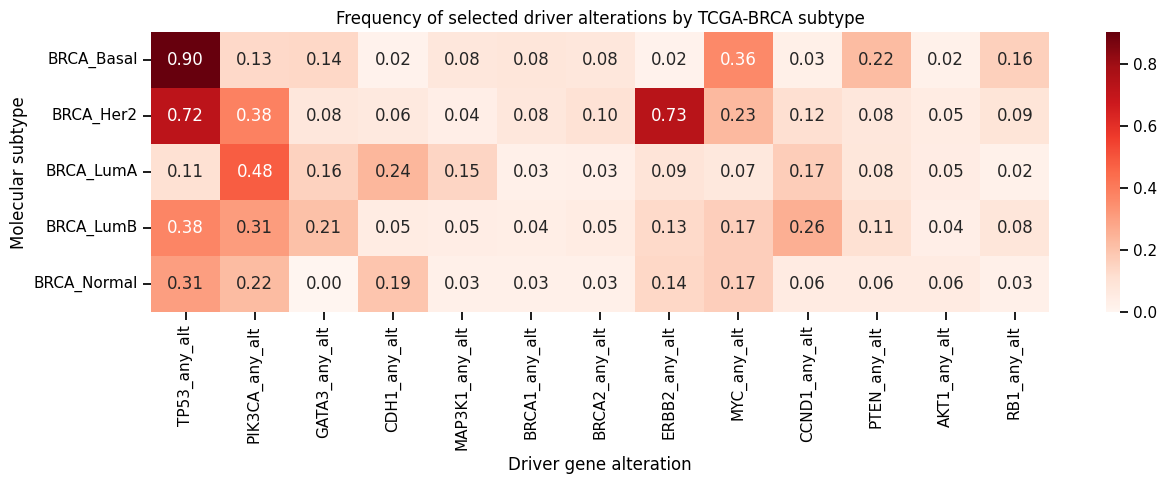

In [42]:
plt.figure(figsize=(13, 5))
sns.heatmap(
    freq_by_subtype,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=max(0.5, freq_by_subtype.max().max())
)

plt.title("Frequency of selected driver alterations by TCGA-BRCA subtype")
plt.xlabel("Driver gene alteration")
plt.ylabel("Molecular subtype")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "driver_any_alteration_frequency_by_subtype_heatmap.png",
    dpi=300
)

plt.show()

,TP53_mut,PIK3CA_mut,GATA3_mut,MAP3K1_mut,CDH1_mut,BRCA1_mut,BRCA2_mut,ERBB2_amp,MYC_amp,CCND1_amp,PTEN_del,RB1_del
SUBTYPE,,,,,,,,,,,,
BRCA_Basal,0.894737,0.070175,0.000000,0.029240,0.005848,0.076023,0.035088,0.011696,0.356725,0.029240,0.163743,0.111111
BRCA_Her2,0.705128,0.333333,0.038462,0.038462,0.038462,0.025641,0.089744,0.705128,0.230769,0.115385,0.012821,0.064103
BRCA_LumA,0.106212,0.474950,0.154309,0.142285,0.218437,0.018036,0.018036,0.062124,0.072144,0.170341,0.020040,0.014028
BRCA_LumB,0.360406,0.299492,0.203046,0.035533,0.045685,0.015228,0.020305,0.121827,0.162437,0.258883,0.050761,0.040609
BRCA_Normal,0.305556,0.222222,0.000000,0.027778,0.166667,0.000000,0.000000,0.083333,0.166667,0.055556,0.027778,0.027778


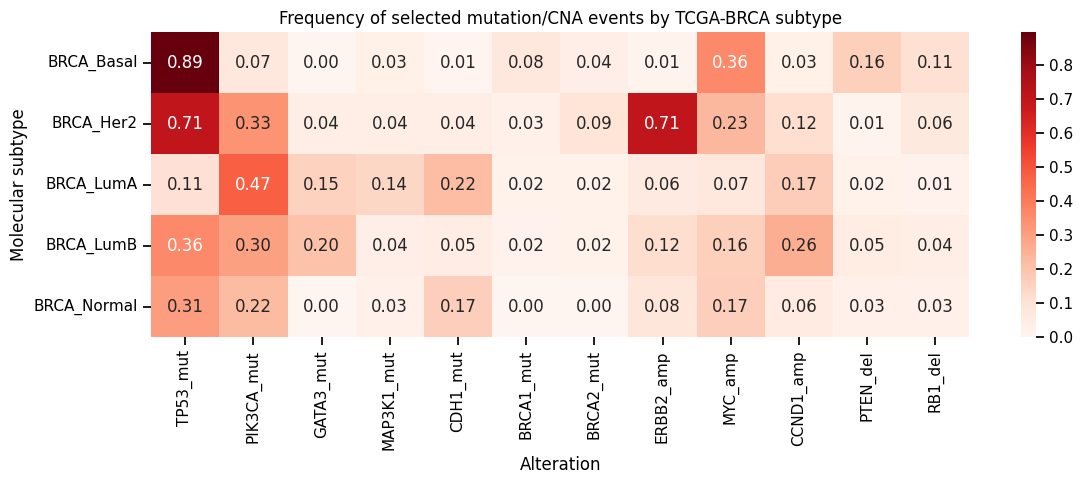

In [43]:
selected_specific_alts = [
    "TP53_mut",
    "PIK3CA_mut",
    "GATA3_mut",
    "MAP3K1_mut",
    "CDH1_mut",
    "BRCA1_mut",
    "BRCA2_mut",
    "ERBB2_amp",
    "MYC_amp",
    "CCND1_amp",
    "PTEN_del",
    "RB1_del",
]

selected_specific_alts = [
    col for col in selected_specific_alts
    if col in driver_table.columns
]

specific_freq_by_subtype = (
    driver_table[driver_table["SUBTYPE"].isin(analysis_subtypes)]
    .groupby("SUBTYPE")[selected_specific_alts]
    .mean()
    .loc[analysis_subtypes]
)

display(specific_freq_by_subtype)

specific_freq_by_subtype.to_csv(
    TABLES_DIR / "selected_specific_alteration_frequency_by_subtype.csv"
)

plt.figure(figsize=(12, 5))
sns.heatmap(
    specific_freq_by_subtype,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=max(0.5, specific_freq_by_subtype.max().max())
)

plt.title("Frequency of selected mutation/CNA events by TCGA-BRCA subtype")
plt.xlabel("Alteration")
plt.ylabel("Molecular subtype")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "selected_specific_alteration_frequency_by_subtype_heatmap.png",
    dpi=300
)

plt.show()

In [44]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n = len(p_values)

    order = np.argsort(p_values)
    ranked = p_values[order]

    adjusted = ranked * n / np.arange(1, n + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)

    adjusted_original = np.empty_like(adjusted)
    adjusted_original[order] = adjusted

    return adjusted_original


enrichment_rows = []

subtype_df = driver_table[driver_table["SUBTYPE"].isin(analysis_subtypes)].copy()

for subtype in analysis_subtypes:
    subtype_mask = subtype_df["SUBTYPE"] == subtype
    rest_mask = subtype_df["SUBTYPE"] != subtype
    
    for alt in selected_specific_alts:
        a = subtype_df.loc[subtype_mask, alt].sum()
        b = subtype_mask.sum() - a
        c = subtype_df.loc[rest_mask, alt].sum()
        d = rest_mask.sum() - c
        
        odds_ratio, p_value = fisher_exact([[a, b], [c, d]])
        
        enrichment_rows.append(
            {
                "subtype": subtype,
                "alteration": alt,
                "n_subtype": subtype_mask.sum(),
                "n_rest": rest_mask.sum(),
                "freq_subtype": a / subtype_mask.sum(),
                "freq_rest": c / rest_mask.sum(),
                "odds_ratio": odds_ratio,
                "p_value": p_value,
            }
        )

enrichment_df = pd.DataFrame(enrichment_rows)
enrichment_df["fdr"] = benjamini_hochberg(enrichment_df["p_value"].values)

enrichment_df = enrichment_df.sort_values(["fdr", "p_value"])

display(enrichment_df.head(30))

enrichment_df.to_csv(
    TABLES_DIR / "selected_driver_alteration_subtype_enrichment.csv",
    index=False
)

,subtype,alteration,n_subtype,n_rest,freq_subtype,freq_rest,odds_ratio,p_value,fdr
24,BRCA_LumA,TP53_mut,499,482,0.106212,0.601660,0.078676,2.319568e-63,1.391741e-61
0,BRCA_Basal,TP53_mut,171,810,0.894737,0.234568,27.736842,9.432662e-61,2.829798e-59
19,BRCA_Her2,ERBB2_amp,78,903,0.705128,0.066445,33.597826,3.526014e-39,7.052028e-38
1,BRCA_Basal,PIK3CA_mut,171,810,0.070175,0.407407,0.109777,2.757519e-20,4.136278e-19
28,BRCA_LumA,CDH1_mut,499,482,0.218437,0.039419,6.810661,4.904710e-18,5.885652e-17
25,BRCA_LumA,PIK3CA_mut,499,482,0.474950,0.217842,3.247874,1.815256e-17,1.815256e-16
32,BRCA_LumA,MYC_amp,499,482,0.072144,0.242739,0.242565,8.477134e-14,7.266115e-13
8,BRCA_Basal,MYC_amp,171,810,0.356725,0.113580,4.327866,3.022192e-13,2.266644e-12
2,BRCA_Basal,GATA3_mut,171,810,0.000000,0.148148,0.000000,3.229012e-11,2.130584e-10
12,BRCA_Her2,TP53_mut,78,903,0.705128,0.318937,5.106431,3.550973e-11,2.130584e-10


In [46]:
interesting_enrichments = enrichment_df[
    (enrichment_df["freq_subtype"] >= 0.10)
    & (enrichment_df["odds_ratio"] > 2)
].copy()

display(
    interesting_enrichments[
        [
            "subtype",
            "alteration",
            "freq_subtype",
            "freq_rest",
            "odds_ratio",
            "p_value",
            "fdr",
        ]
    ].head(30)
)

,subtype,alteration,freq_subtype,freq_rest,odds_ratio,p_value,fdr
0,BRCA_Basal,TP53_mut,0.894737,0.234568,27.736842,9.432662e-61,2.829798e-59
19,BRCA_Her2,ERBB2_amp,0.705128,0.066445,33.597826,3.526014e-39,7.052028e-38
28,BRCA_LumA,CDH1_mut,0.218437,0.039419,6.810661,4.904710e-18,5.885652e-17
25,BRCA_LumA,PIK3CA_mut,0.474950,0.217842,3.247874,1.815256e-17,1.815256e-16
8,BRCA_Basal,MYC_amp,0.356725,0.113580,4.327866,3.022192e-13,2.266644e-12
12,BRCA_Her2,TP53_mut,0.705128,0.318937,5.106431,3.550973e-11,2.130584e-10
10,BRCA_Basal,PTEN_del,0.163743,0.027160,7.013350,2.234906e-10,1.117453e-09
27,BRCA_LumA,MAP3K1_mut,0.142285,0.033195,4.831484,8.312325e-10,3.836457e-09
11,BRCA_Basal,RB1_del,0.111111,0.025926,4.696429,6.880507e-06,2.381798e-05
45,BRCA_LumB,CCND1_amp,0.258883,0.128827,2.362200,2.234430e-05,6.703291e-05


## Interpretation

This analysis integrates TCGA-BRCA subtype annotations with mutation and copy-number alteration data.

Unlike the previous supervised subtype prediction notebook, this analysis is not trying to predict subtype from expression. Instead, it asks whether known breast cancer driver alterations are distributed differently across transcriptomic subtypes.

Key points to evaluate:

1. Whether TP53 mutation is enriched in Basal-like tumours.
2. Whether PIK3CA, GATA3, MAP3K1 or CDH1 mutations are more frequent in luminal subtypes.
3. Whether ERBB2 amplification is enriched in HER2-enriched samples.
4. Whether Normal-like samples show a distinct or lower-frequency driver alteration pattern.
5. Whether copy-number events such as MYC amplification, CCND1 amplification, PTEN deletion or RB1 deletion show subtype-associated patterns.

This is an exploratory multi-omic analysis. Results should be interpreted as hypothesis-generating rather than clinically validated biomarkers.

## Key findings

This multi-omic analysis identified subtype-associated genomic alteration patterns in TCGA-BRCA.

Basal-like tumours showed strong enrichment of TP53 mutation, together with increased frequencies of MYC amplification, PTEN deletion and RB1 deletion. HER2-enriched tumours showed strong enrichment of ERBB2 amplification, linking transcriptomic subtype identity with a known copy-number driver event. Luminal A tumours were characterized by higher frequencies of PIK3CA, CDH1 and MAP3K1 mutations and lower TP53 mutation frequency. Luminal B showed an intermediate profile, including higher CCND1 amplification and GATA3 mutation frequency.

Normal-like samples were retained as an annotated subtype, but interpretation should be cautious because this group contains fewer samples.

Overall, this analysis supports the value of integrating transcriptomic subtype annotations with mutation and copy-number data to characterize breast cancer molecular heterogeneity.